In [42]:
import torch
print(torch.__version__)

2.10.0+cpu


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('merged_output.csv')

In [3]:
# Convert to datetime
df['CreatedOn'] = pd.to_datetime(df['CreatedOn'])

# Sort by date
df = df.sort_values(['district', 'CreatedOn'])

# Aggregate monthly pest counts
df['year_month'] = df['CreatedOn'].dt.to_period('M')

df_monthly = df.groupby(['district', 'year_month']).agg({
    'pest_count': 'sum',
    'latitude': 'first',
    'longitude': 'first'
}).reset_index()

# Convert period to timestamp
df_monthly['year_month'] = df_monthly['year_month'].dt.to_timestamp()

# Sort again
df_monthly = df_monthly.sort_values(['district', 'year_month'])

df_monthly.head()

,district,year_month,pest_count,latitude,longitude
0,24 PARGANAS (NORTH DISTRICT),2013-04-01,21,22.591967,88.39957
1,24 PARGANAS (NORTH DISTRICT),2013-05-01,24,22.591967,88.39957
2,24 PARGANAS (NORTH DISTRICT),2013-06-01,15,22.591967,88.39957
3,24 PARGANAS (NORTH DISTRICT),2013-07-01,14,22.591967,88.39957
4,24 PARGANAS (NORTH DISTRICT),2013-09-01,22,22.591967,88.39957


In [5]:
from sklearn.neighbors import kneighbors_graph

# Unique districts with coordinates
district_coords = df_monthly[['district', 'latitude', 'longitude']].drop_duplicates().reset_index(drop=True)

# Create adjacency matrix (5 nearest neighbors)
A = kneighbors_graph(
    district_coords[['latitude', 'longitude']],
    n_neighbors=10,
    mode='connectivity',
    include_self=False
)

A = A.toarray()
print(district_coords)
print(A)

                         district   latitude  longitude
0    24 PARGANAS (NORTH DISTRICT)  22.591967  88.399570
1    24 PARGANAS (SOUTH DISTRICT)  22.591967  88.399570
2                        ADILABAD  19.675945  78.533990
3                            AGAR  23.712727  76.017693
4                            AGRA  27.175255  78.009816
..                            ...        ...        ...
538                  WEST TRIPURA  23.916667  91.500000
539                         WOKHA  26.097896  94.254845
540                      YADAGIRI  16.768904  77.138038
541                  YAMUNA NAGAR  30.130000  77.280000
542                      YEVATMAL  20.390000  78.130000

[543 rows x 3 columns]
[[0. 1. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]]


In [7]:
# Pivot to time x district matrix
pivot_df = df_monthly.pivot(index='year_month', 
                            columns='district', 
                            values='pest_count')

pivot_df = pivot_df.fillna(0)

# Convert to numpy
X = pivot_df.values   # shape = (time_steps, districts)

# Normalize
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Add feature dimension
X_scaled = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

print(X_scaled.shape)

(57, 543, 1)


In [9]:
def create_sequences(data, seq_length=12):
    X_seq = []
    y_seq = []

    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i+seq_length])
        y_seq.append(data[i+seq_length])

    return np.array(X_seq), np.array(y_seq)

seq_length = 12
X_seq, y_seq = create_sequences(X_scaled, seq_length)

print(X_seq.shape, y_seq.shape)

(45, 12, 543, 1) (45, 543, 1)


In [11]:
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv
from torch_geometric.utils import dense_to_sparse

# Convert adjacency matrix to edge_index
edge_index, _ = dense_to_sparse(torch.tensor(A, dtype=torch.float))


class STGCN(nn.Module):

    def __init__(self, num_nodes, in_channels=1, gcn_hidden=16, lstm_hidden=32):
        super(STGCN, self).__init__()

        self.gcn = GCNConv(in_channels, gcn_hidden)
        self.lstm = nn.LSTM(gcn_hidden, lstm_hidden, batch_first=True)
        self.fc = nn.Linear(lstm_hidden, 1)

        self.num_nodes = num_nodes

    def forward(self, x):

        # x shape: (batch, seq_len, nodes, features)
        batch_size, seq_len, num_nodes, features = x.shape

        # Last input (for residual connection)
        last_input = x[:, -1, :, :]

        # ---- Create batched edge index ----
        edge_index_batch = []
        for i in range(batch_size):
            offset = i * num_nodes
            edge_index_batch.append(edge_index + offset)

        edge_index_batch = torch.cat(edge_index_batch, dim=1)
        edge_index_batch = edge_index_batch.to(x.device)

        gcn_out_seq = []

        # ---- Spatial GCN for each time step ----
        for t in range(seq_len):

            xt = x[:, t, :, :]   # (batch, nodes, features)

            xt = xt.reshape(batch_size * num_nodes, features)

            gcn_out = self.gcn(xt, edge_index_batch)

            gcn_out = gcn_out.reshape(batch_size, num_nodes, -1)

            gcn_out_seq.append(gcn_out)

        # Stack time steps
        gcn_out_seq = torch.stack(gcn_out_seq, dim=1)

        # ---- Temporal modeling with LSTM ----
        gcn_out_seq = gcn_out_seq.reshape(batch_size * num_nodes, seq_len, -1)

        lstm_out, _ = self.lstm(gcn_out_seq)

        # Use last time step
        out = self.fc(lstm_out[:, -1, :])

        out = out.reshape(batch_size, num_nodes, 1)

        # ---- Residual connection ----
        out = out + last_input

        return out

In [13]:
# Chronological split (80% train, 20% test)

train_size = int(0.8 * len(X_seq))

X_train = X_seq[:train_size]
y_train = y_seq[:train_size]

X_test = X_seq[train_size:]
y_test = y_seq[train_size:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (36, 12, 543, 1)
Test shape: (9, 12, 543, 1)


In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train_tensor = torch.tensor(X_train, dtype=torch.float).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float).to(device)

X_test_tensor = torch.tensor(X_test, dtype=torch.float).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float).to(device)

In [17]:
model = STGCN(num_nodes=X_seq.shape[2]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 500

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    output = model(X_train_tensor)
    loss = criterion(output, y_train_tensor)

    loss.backward()
    optimizer.step()

    
    print(f"Epoch {epoch}, Train Loss: {loss.item()}")


Epoch 0, Train Loss: 0.1262732744216919
Epoch 1, Train Loss: 0.12210103869438171
Epoch 2, Train Loss: 0.1182275116443634
Epoch 3, Train Loss: 0.11463983356952667
Epoch 4, Train Loss: 0.11132317036390305
Epoch 5, Train Loss: 0.10826130211353302
Epoch 6, Train Loss: 0.1054382249712944
Epoch 7, Train Loss: 0.10283928364515305
Epoch 8, Train Loss: 0.10045136511325836
Epoch 9, Train Loss: 0.0982629582285881
Epoch 10, Train Loss: 0.09626423567533493
Epoch 11, Train Loss: 0.09444722533226013
Epoch 12, Train Loss: 0.09280598163604736
Epoch 13, Train Loss: 0.09133654087781906
Epoch 14, Train Loss: 0.09003664553165436
Epoch 15, Train Loss: 0.08890552073717117
Epoch 16, Train Loss: 0.08794321864843369
Epoch 17, Train Loss: 0.08715012669563293
Epoch 18, Train Loss: 0.08652599900960922
Epoch 19, Train Loss: 0.08606889843940735
Epoch 20, Train Loss: 0.08577373623847961
Epoch 21, Train Loss: 0.08563048392534256
Epoch 22, Train Loss: 0.08562221378087997
Epoch 23, Train Loss: 0.08572335541248322
Epoch 

In [19]:
model.eval()

with torch.no_grad():
    test_predictions = model(X_test_tensor)

# Move to CPU
test_predictions = test_predictions.cpu().numpy()
y_test_actual = y_test_tensor.cpu().numpy()

In [21]:
test_predictions = test_predictions.reshape(-1)
y_test_actual = y_test_actual.reshape(-1)


In [23]:
# We must reshape back to original format for inverse scaling

num_districts = pivot_df.shape[1]

pred_reshaped = test_predictions.reshape(-1, num_districts)
actual_reshaped = y_test_actual.reshape(-1, num_districts)

pred_inverse = scaler.inverse_transform(pred_reshaped)
actual_inverse = scaler.inverse_transform(actual_reshaped)

# Flatten again
pred_inverse = pred_inverse.flatten()
actual_inverse = actual_inverse.flatten()

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(actual_inverse, pred_inverse)
rmse = np.sqrt(mean_squared_error(actual_inverse, pred_inverse))
r2 = r2_score(actual_inverse, pred_inverse)

mape = np.mean(np.abs((actual_inverse - pred_inverse) / 
                      (actual_inverse + 1e-8))) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)


MAE : 16.44218635559082
RMSE: 41.09380941060344
R2  : 0.18608224391937256


In [28]:
district_mae = []

for i in range(num_districts):
    mae_d = mean_absolute_error(actual_reshaped[:, i],
                                pred_reshaped[:, i])
    district_mae.append(mae_d)

district_results = pd.DataFrame({
    'district': pivot_df.columns,
    'MAE': district_mae
})

district_results.sort_values('MAE')

,district,MAE
47,BANGALORE (URBAN),0.001233
501,TIRAP,0.001413
539,WOKHA,0.002049
263,KASARGOD,0.002060
277,KISHTWAR,0.002346
...,...,...
336,MORADABAD,0.390468
265,KATIHAR,0.400344
194,HAMIRPUR,0.474630
125,DEHRADUN,0.479602


In [30]:
# reshape back
num_districts = pivot_df.shape[1]

pred_full = pred_inverse.reshape(-1, num_districts)
actual_full = actual_inverse.reshape(-1, num_districts)

# Sum across all districts
total_pred = pred_full.sum(axis=1)
total_actual = actual_full.sum(axis=1)


In [32]:
# Original total pest counts
total_series = pivot_df.sum(axis=1)

# Remove first seq_length months
total_series_seq = total_series[seq_length:]

train_total = total_series_seq[:train_size]
test_total  = total_series_seq[train_size:]

# Dates
dates_seq = pivot_df.index[seq_length:]
train_dates = dates_seq[:train_size]
test_dates  = dates_seq[train_size:]



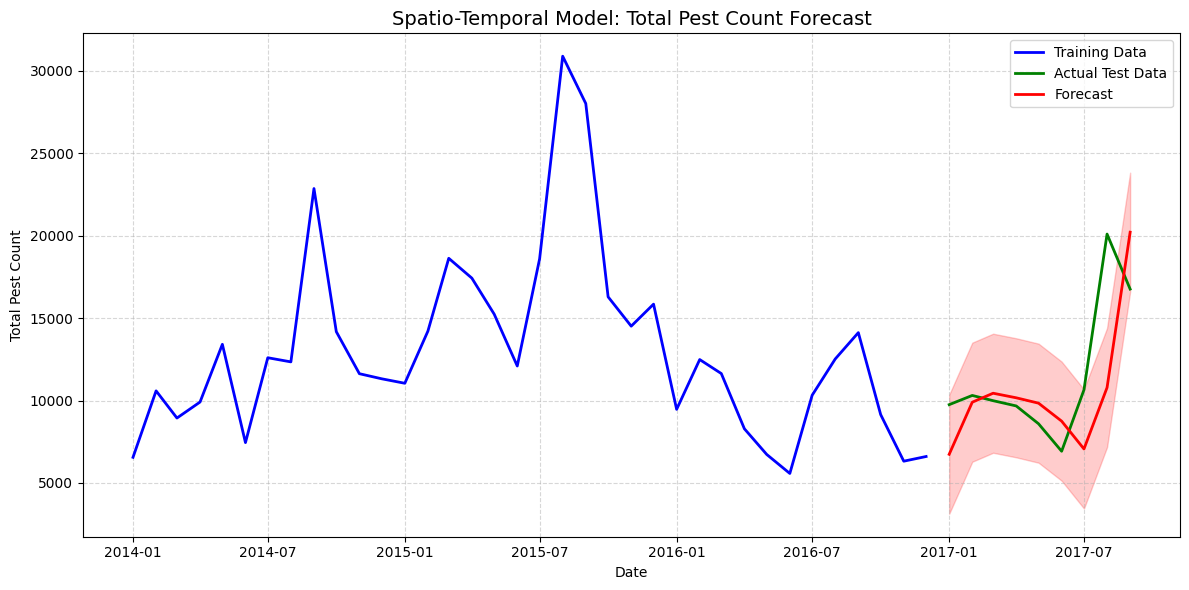

In [34]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))

# Training data
plt.plot(train_dates,
         train_total,
         label='Training Data',
         color='blue',
         linewidth=2)

# Actual test
plt.plot(test_dates,
         total_actual,
         label='Actual Test Data',
         color='green',
         linewidth=2)

# Predicted test
plt.plot(test_dates,
         total_pred,
         label='Forecast',
         color='red',
         linewidth=2)

# Confidence band (approximate)
error_std = np.std(total_actual - total_pred)

plt.fill_between(test_dates,
                 total_pred - error_std,
                 total_pred + error_std,
                 color='red',
                 alpha=0.2)

plt.title("Spatio-Temporal Model: Total Pest Count Forecast", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Pest Count")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

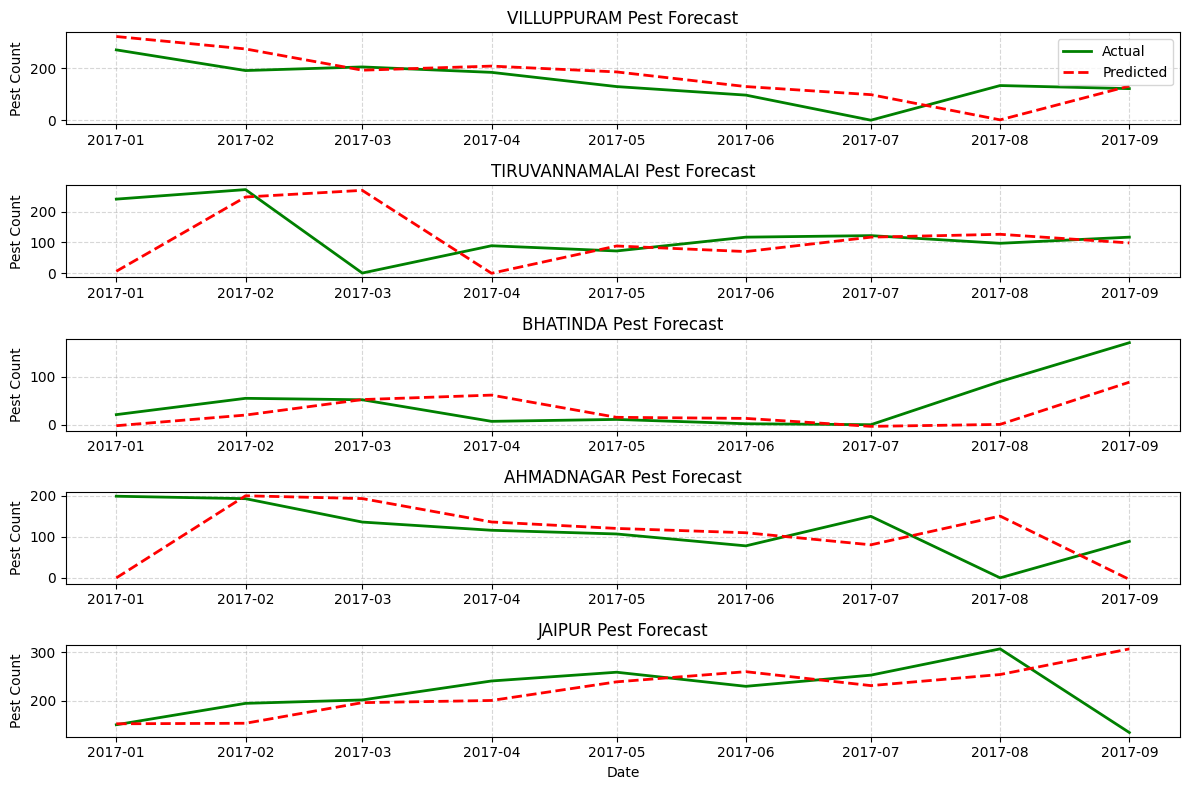

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Number of districts to plot
num_plot = 5

# Select districts with highest total pest counts
top_district_idx = pivot_df.sum().sort_values(ascending=False).index[:num_plot]

plt.figure(figsize=(12,8))

for i, district in enumerate(top_district_idx):

    d_idx = pivot_df.columns.get_loc(district)

    actual_d = actual_full[:, d_idx]
    pred_d   = pred_full[:, d_idx]

    plt.subplot(num_plot,1,i+1)

    plt.plot(test_dates, actual_d, label='Actual', color='green', linewidth=2)
    plt.plot(test_dates, pred_d, label='Predicted', color='red', linestyle='--', linewidth=2)

    plt.title(f"{district} Pest Forecast")
    plt.ylabel("Pest Count")
    plt.grid(True, linestyle="--", alpha=0.5)

    if i == 0:
        plt.legend()

plt.xlabel("Date")
plt.tight_layout()
plt.show()

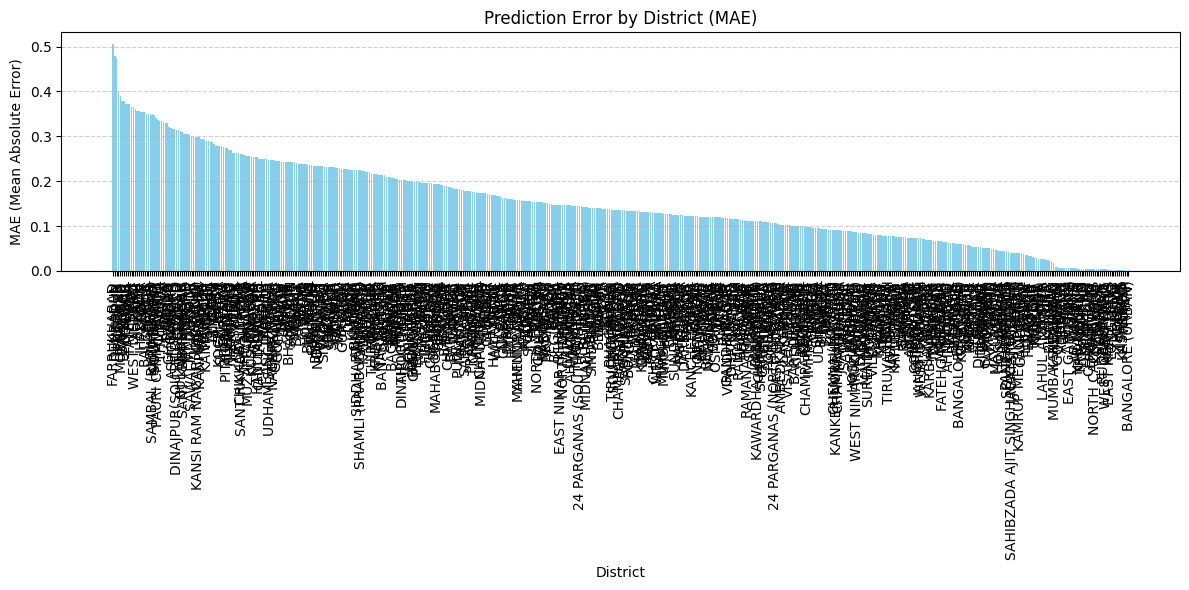

In [38]:
import matplotlib.pyplot as plt

# Sort districts by MAE
district_results_sorted = district_results.sort_values('MAE', ascending=False)

plt.figure(figsize=(12,6))

plt.bar(district_results_sorted['district'],
        district_results_sorted['MAE'],
        color='skyblue')

plt.xticks(rotation=90)
plt.xlabel("District")
plt.ylabel("MAE (Mean Absolute Error)")
plt.title("Prediction Error by District (MAE)")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

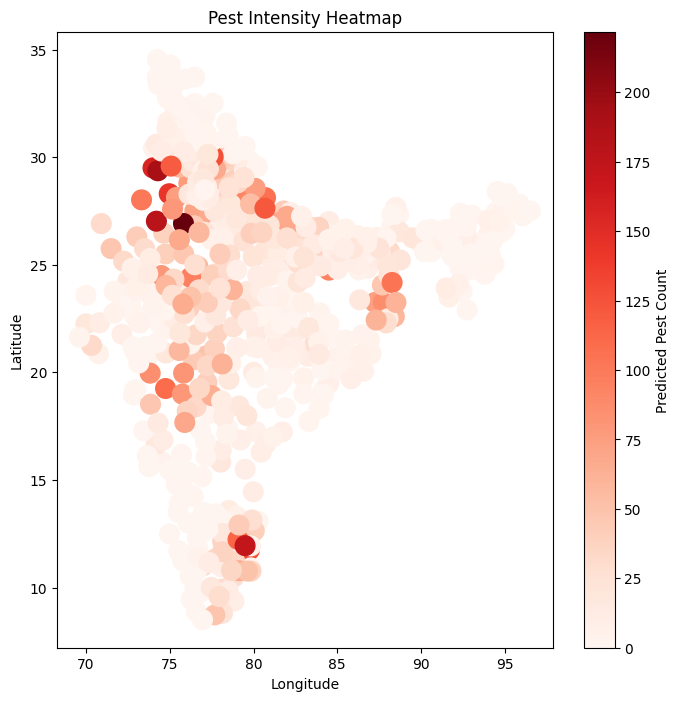

In [40]:
import matplotlib.pyplot as plt

district_pred = pd.DataFrame({
    "district": pivot_df.columns,
    "pest_pred": pred_full.mean(axis=0)
})

district_coords = df_monthly[['district','latitude','longitude']].drop_duplicates()

heatmap_data = district_coords.merge(district_pred,on="district")

plt.figure(figsize=(8,8))

plt.scatter(
    heatmap_data["longitude"],
    heatmap_data["latitude"],
    c=heatmap_data["pest_pred"],
    cmap="Reds",
    s=200
)

plt.colorbar(label="Predicted Pest Count")
plt.title("Pest Intensity Heatmap")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()